<a href="https://colab.research.google.com/github/ankitha-454/pcos-project/blob/main/PCOS_Backend_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy pandas scikit-learn matplotlib seaborn flask flask-cors

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
np.random.seed(42)

n = 5000

data = {
    "age": np.random.randint(18,45,n),
    "bmi": np.random.uniform(18,35,n),
    "cycle": np.random.randint(21,50,n),
    "lh": np.random.uniform(2,20,n),
    "fsh": np.random.uniform(2,15,n),
    "insulin": np.random.uniform(5,30,n),
    "acne": np.random.randint(0,3,n),
    "hair": np.random.randint(0,3,n)
}

df = pd.DataFrame(data)
df.head()

,age,bmi,cycle,lh,fsh,insulin,acne,hair
0,24,26.613435,41,11.990333,3.015356,18.791168,1,1
1,37,24.583034,23,7.169826,14.261120,11.384934,1,0
2,32,33.411728,47,18.923169,3.291976,15.890495,1,0
3,28,18.273052,46,15.717290,13.112844,17.907900,2,0
4,25,31.296911,31,19.505261,2.004027,7.417996,2,0


In [ ]:
df["pcos"] = (
    (df["bmi"] > 27).astype(int) +
    (df["cycle"] > 35).astype(int) +
    ((df["lh"]/df["fsh"]) > 2).astype(int)
)

df["pcos"] = (df["pcos"] > 1).astype(int)

df.head()

,age,bmi,cycle,lh,fsh,insulin,acne,hair,pcos
0,24,26.613435,41,11.990333,3.015356,18.791168,1,1,1
1,37,24.583034,23,7.169826,14.261120,11.384934,1,0,0
2,32,33.411728,47,18.923169,3.291976,15.890495,1,0,1
3,28,18.273052,46,15.717290,13.112844,17.907900,2,0,0
4,25,31.296911,31,19.505261,2.004027,7.417996,2,0,1


In [ ]:
X = df.drop("pcos", axis=1)
y = df["pcos"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.987


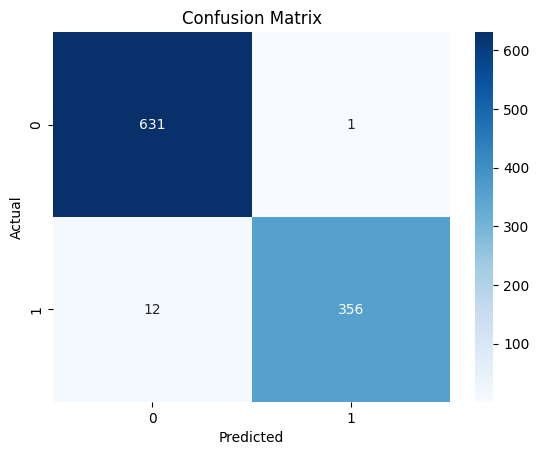

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
df["PCOS_Probability"] = model.predict_proba(X)[:,1]

df["Cancer_Risk"] = (
    df["PCOS_Probability"] * 25 +
    (df["age"] > 40) * 15 +
    ((df["age"] > 30) & (df["age"] <= 40)) * 8 +
    (df["bmi"] > 30) * 10 +
    ((df["bmi"] > 25) & (df["bmi"] <= 30)) * 5 +
    (df["insulin"] > 20) * 8
)

df["Cancer_Risk"] = df["Cancer_Risk"].clip(0,100)

df.head()

,age,bmi,cycle,lh,fsh,insulin,acne,hair,pcos,PCOS_Probability,Cancer_Risk
0,24,26.613435,41,11.990333,3.015356,18.791168,1,1,1,0.98,29.50
1,37,24.583034,23,7.169826,14.261120,11.384934,1,0,0,0.00,8.00
2,32,33.411728,47,18.923169,3.291976,15.890495,1,0,1,1.00,43.00
3,28,18.273052,46,15.717290,13.112844,17.907900,2,0,0,0.00,0.00
4,25,31.296911,31,19.505261,2.004027,7.417996,2,0,1,0.99,34.75


In [ ]:
sample = [[28, 24.5, 30, 8, 6, 12, 1, 1]]
sample_df = pd.DataFrame(sample, columns=X.columns)

prediction = model.predict(sample_df)
probability = model.predict_proba(sample_df)

print("PCOS Prediction:", prediction)
print("PCOS Probability:", probability)

PCOS Prediction: [0]
PCOS Probability: [[1. 0.]]


In [ ]:
sample = [[32, 30, 45, 15, 5, 25, 2, 2]]
sample_df = pd.DataFrame(sample, columns=X.columns)

prediction = model.predict(sample_df)
probability = model.predict_proba(sample_df)

print("PCOS Prediction:", prediction)
print("PCOS Probability:", probability)

PCOS Prediction: [1]
PCOS Probability: [[0. 1.]]


In [ ]:
#sample = [[32, 30, 45, 15, 5, 25, 2, 2]]
sample = [[28, 24.5, 30, 8, 6, 12, 1, 1]]

sample_df = pd.DataFrame(sample, columns=X.columns)

prediction = model.predict(sample_df)
probability = model.predict_proba(sample_df)

print("PCOS Prediction:", prediction)
print("PCOS Probability:", probability)

# Extract values
age = sample_df["age"].values[0]
bmi = sample_df["bmi"].values[0]
insulin = sample_df["insulin"].values[0]

# PCOS probability
pcos_prob = probability[0][1]

# Cancer risk formula
cancer_risk = (
    pcos_prob * 25 +
    (age > 40) * 15 +
    ((age > 30) & (age <= 40)) * 8 +
    (bmi > 30) * 10 +
    ((bmi > 25) & (bmi <= 30)) * 5 +
    (insulin > 20) * 8
)

cancer_risk = min(100, cancer_risk)

print("Cancer Risk:", round(cancer_risk,2), "%")

PCOS Prediction: [0]
PCOS Probability: [[1. 0.]]
Cancer Risk: 0.0 %
